In [1]:
import numpy as np
import VBMicrolensing as VBM
import math
import matplotlib.pyplot as plt

v = VBM.VBMicrolensing()
v.astrometry = True
v.RelTol = 1e-3
v.Tol = 1e-3
v.SetObjectCoordinates("0:0:0 0:0:0")

In [2]:
help(v.TripleAstroLightCurve)

Help on method TripleAstroLightCurve in module VBMicrolensing.VBMicrolensing:

TripleAstroLightCurve(...) method of VBMicrolensing.VBMicrolensing.VBMicrolensing instance
    Triple light curve and astrometry for a full array of observations.

    Parameters
    ----------
    params : list[float]
        List of parameters [log_s, log_q, u0, alpha, log_rho, log_tE, t0,
                            log(s13), log(q3), psi
                            paiN, paiE,     #components of the parallax vector
                            muS_N, muS_E,   # proper motion components of the source (mas/yr)
                            pai_S,          # parallax of the source (mas)
                            thetaE          # Einstein angle (mas)
                            ]
    times : list[float]
        Array of times at which the magnification is calculated.

    Returns
    -------
    results: list[list[float],list[float],list[float],list[float],list[float],list[float],list[float]]
        [Magnif

In [ ]:
s12 = 1.3
q2  = 1e-3
s23 = 1.3003845585056752
q3  = 1e-5

u0     = 0.0155      
alpha  = 0       # radians = 90 degrees = -1.5708 
rho    = 1.8e-3
tE     = 20
t0     = 0
psi    = -0.024320416600791351647 #radians =1.393457227228705 degrees
paiN  = 0.0
paiE  = 0.0
muS_N = 0.0
muS_E = 0.0
pai_S = 0.0
thetaE = 0.32  # mas


params = [
    np.log(s12), np.log(q2), u0, alpha,
    np.log(rho), np.log(tE), t0,
    np.log(s23), np.log(q3), psi,
    paiN, paiE, muS_N, muS_E, pai_S, thetaE
]

t = np.linspace(-20, 20, 100)


results = v.TripleAstroLightCurve(params, list(t))

mag, cI_N, cI_E, cL_N, cL_E, y1, y2 = results

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

In [ ]:
print(t)

[-20.        -19.9979999 -19.9959998 ...  19.9959998  19.9979999
  20.       ]


In [ ]:
caustics = v.Multicaustics()

In [ ]:
params_lc = [
    np.log(s12), np.log(q2), u0, alpha,
    np.log(rho), np.log(tE), t0,
    np.log(s23), np.log(q3), psi
]


magtriple = v.TripleLightCurve(params_lc, t)


caustics = v.Multicaustics()

y1_src = np.array(magtriple[2])
y2_src = np.array(magtriple[1])


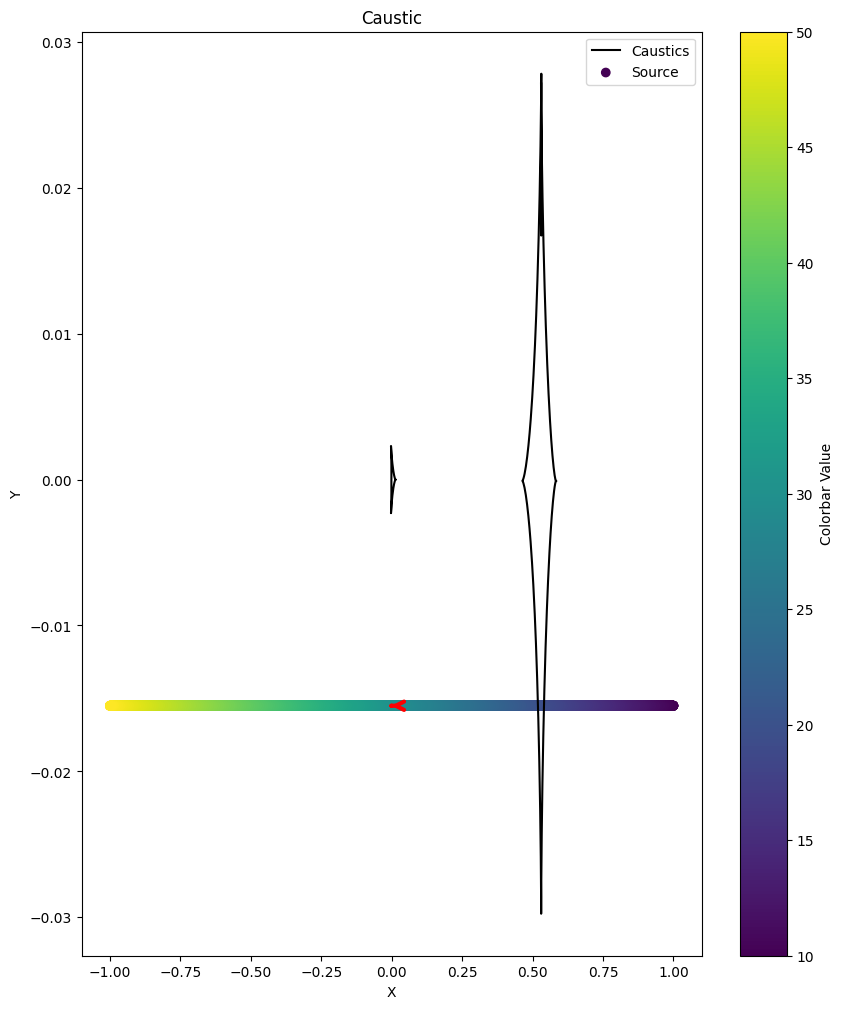

In [ ]:
fig2, ax2 = plt.subplots(figsize=(10,12))

first = True
for cau in caustics:
    x, y = cau
    if first:
        ax2.plot(x, y, 'k-', label='Caustics')
        first = False
    else:
        ax2.plot(x, y, 'k-')

im = ax2.scatter(y2_src, y1_src, c=(t + 30), cmap='viridis', label='Source')
cbar = fig2.colorbar(im, ax=ax2, orientation='vertical')
cbar.set_label('Colorbar Value')
mid_x = np.mean(magtriple[1])
mid_y = np.mean(magtriple[2])
delta_x = magtriple[1][-1] - magtriple[1][0]
delta_y = magtriple[2][-1] - magtriple[2][0]
arrow_end_x = mid_x + delta_x * 0.001
arrow_end_y = mid_y + delta_y * 0.001
ax2.annotate('', xy=(arrow_end_x, arrow_end_y), xytext=(mid_x, mid_y),
             arrowprops=dict(arrowstyle='->', color='red', mutation_scale=15, linestyle='-', linewidth=3))

#ax2.set_xlim(0.450, 0.60)
#ax2.set_ylim(-0.035, 0.035)
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_title("Caustic")
ax2.legend()
#ax2.set_aspect("equal")
plt.show()


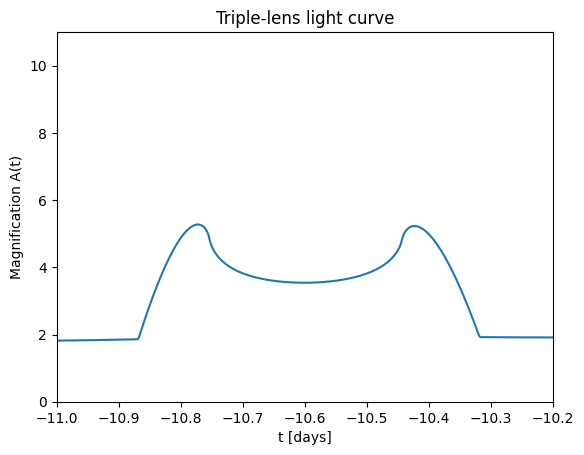

In [ ]:
#light curve
plt.figure()
plt.plot(t, mag)
plt.xlabel("t [days]")
plt.ylabel("Magnification A(t)")
plt.title("Triple-lens light curve")
plt.xlim(-11, -10.2)
plt.ylim(0, 11)
plt.show()

In [ ]:
cI_N = np.array(cI_N)
cI_E = np.array(cI_E)

y1 = np.array(y1)
y2 = np.array(y2)

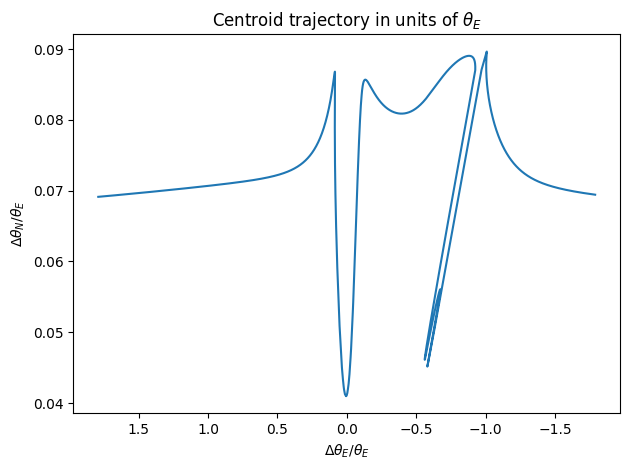

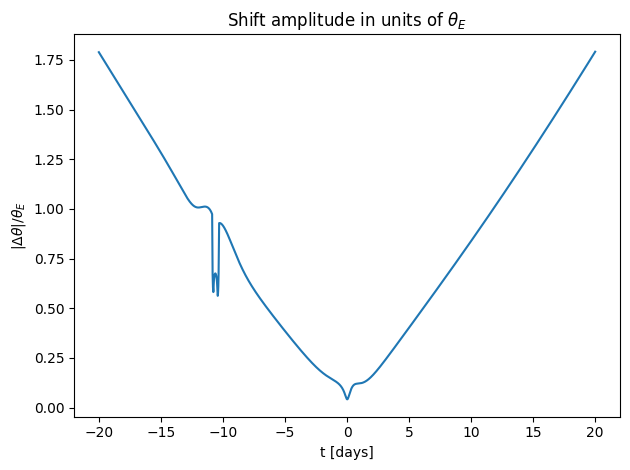

In [ ]:
#centroid shifts
dN = cI_N - y2           # mas
dE = cI_E - y1           # mas
shift = np.sqrt(dN**2 + dE**2)   # mas

dN_thE = dN / thetaE
dE_thE = dE / thetaE
shift_thE = np.sqrt(dN_thE**2 + dE_thE**2)

#centroid trajectory
plt.figure()
plt.plot(dE_thE, dN_thE)
plt.xlabel(r'$\Delta \theta_E / \theta_E$')
plt.ylabel(r'$\Delta \theta_N / \theta_E$')
plt.title('Centroid trajectory in units of $\\theta_E$')
#plt.xlim(0.5, 1.2)
#plt.ylim(-1.4, -2)
plt.gca().invert_xaxis()
plt.tight_layout()

#centroid shift
plt.figure()
plt.plot(t, shift_thE)
plt.xlabel('t [days]')
plt.ylabel(r'$|\Delta \theta| / \theta_E$')
plt.title('Shift amplitude in units of $\\theta_E$')
#plt.xlim(-2, 2)
plt.tight_layout()
plt.show()

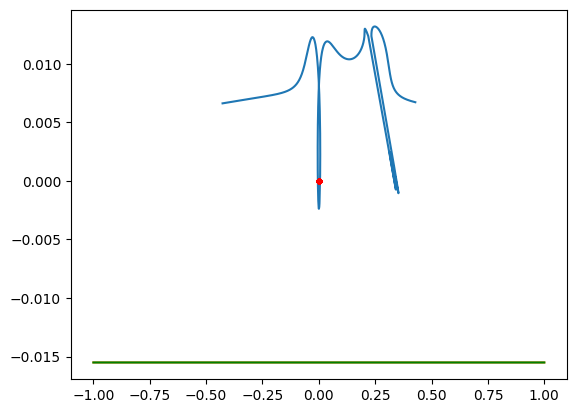

In [ ]:
plt.plot(cI_E, cI_N)
plt.plot(cL_E, cL_N, 'r.')
plt.plot(y1, y2)
plt.plot(y2_src, y1_src, 'g')
#plt.xlim(-0.1, 0.1)

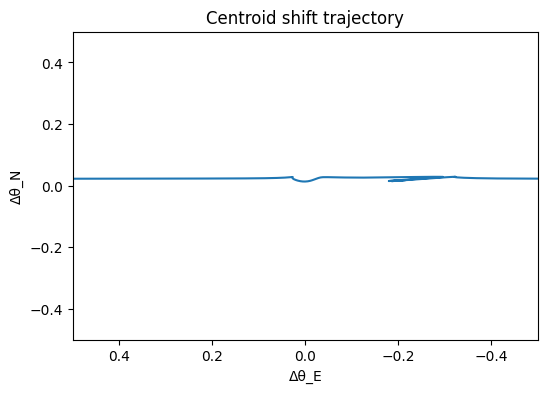

In [ ]:
dN = cI_N - y2
dE = cI_E - y1

plt.figure(figsize=(6,4))
plt.plot(dE, dN)
plt.xlabel("Δθ_E")
plt.ylabel("Δθ_N")
plt.xlim(-0.5, 0.5)
plt.ylim(-0.5, 0.5)
plt.gca().invert_xaxis()
plt.title("Centroid shift trajectory")
plt.show()